# Fraud Detection using Machine Learning

**Task 7 - Credit Card Fraud Detection**

## Key Concepts Covered:
1. **Anomaly Detection** - Identifying unusual transaction patterns
2. **Feature Engineering** - Selecting and transforming relevant features
3. **Machine Learning Models** - Logistic Regression, Decision Tree, Neural Network
4. **Real-time Monitoring** - System design for live fraud detection
5. **Scalability** - Handling large volumes of transactions efficiently

Dataset: 284,807 credit card transactions (492 frauds, 0.17%)

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully')

Libraries imported successfully


## 1. Data Loading & Exploration

In [2]:
# Load dataset
df = pd.read_csv('creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Normal: 284315 | Fraud: 492 (0.1727%)


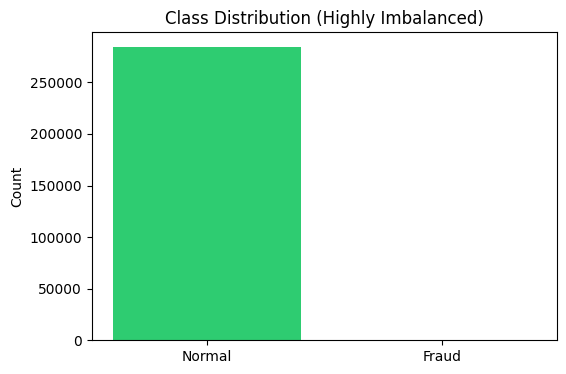

In [3]:
# Class distribution (Anomaly Detection - imbalanced data)
counts = df['Class'].value_counts()
print(f'Normal: {counts[0]} | Fraud: {counts[1]} ({counts[1]/len(df)*100:.4f}%)')

plt.figure(figsize=(6,4))
plt.bar(['Normal', 'Fraud'], counts.values, color=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution (Highly Imbalanced)')
plt.ylabel('Count')
plt.show()

## 2. Exploratory Data Analysis

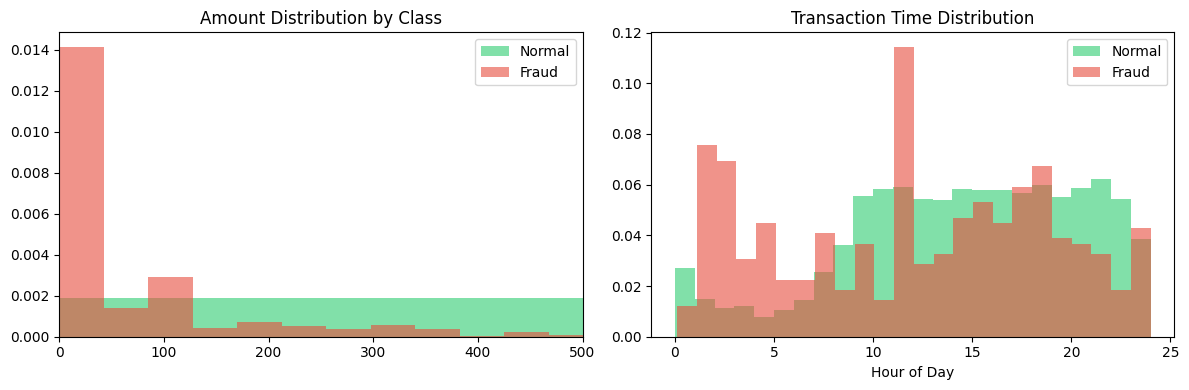

In [4]:
# Transaction amount analysis
fig, axes = plt.subplots(1,2,figsize=(12,4))
for c, col, lbl in zip([0,1], ['#2ecc71','#e74c3c'], ['Normal','Fraud']):
    axes[0].hist(df[df['Class']==c]['Amount'], bins=50, alpha=0.6, color=col, label=lbl, density=True)
axes[0].set_title('Amount Distribution by Class')
axes[0].set_xlim(0,500)
axes[0].legend()

# Time analysis
df['Hour'] = (df['Time']/3600)%24
for c, col, lbl in zip([0,1], ['#2ecc71','#e74c3c'], ['Normal','Fraud']):
    axes[1].hist(df[df['Class']==c]['Hour'], bins=24, alpha=0.6, color=col, label=lbl, density=True)
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Hour of Day')
axes[1].legend()
plt.tight_layout()
plt.show()

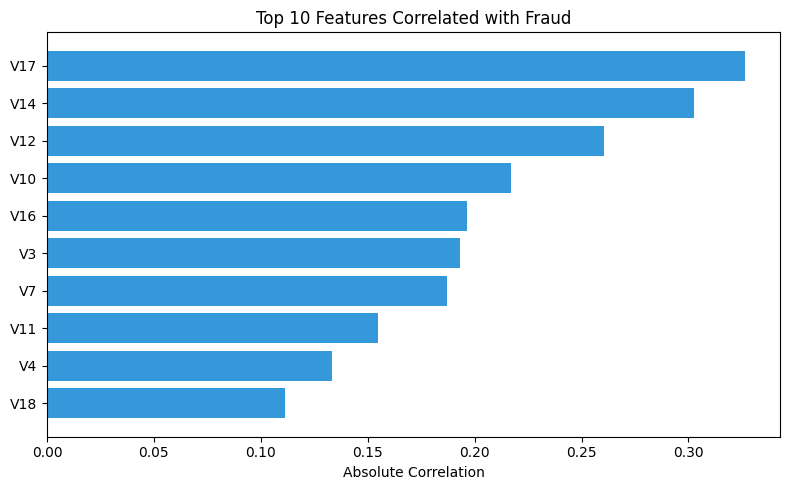

In [5]:
# Feature correlation with target (Feature Engineering insight)
corr = df.drop(['Class','Hour'], axis=1).corrwith(df['Class']).abs().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.barh(range(10), corr.head(10).values[::-1], color='#3498db')
plt.yticks(range(10), corr.head(10).index[::-1])
plt.title('Top 10 Features Correlated with Fraud')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

In [6]:
# Feature Engineering
df['LogAmount'] = np.log1p(df['Amount'])  # Reduce skewness
df['ScaledAmount'] = StandardScaler().fit_transform(df[['Amount']])  # Standardize
df['ScaledTime'] = StandardScaler().fit_transform(df[['Time']])
df['HourBin'] = pd.cut(df['Hour'], bins=4, labels=False)  # Time-based feature

# Prepare feature matrix
features = [c for c in df.columns if c.startswith('V')] + ['ScaledAmount','ScaledTime','LogAmount','HourBin']
X = df[features]
y = df['Class']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

# SMOTE for class imbalance
sm = SMOTE(random_state=42, sampling_strategy=0.2)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f'After SMOTE - Train: {X_train_res.shape[0]} (Fraud: {sum(y_train_res==1)})')

Train: 227845, Test: 56962
After SMOTE - Train: 272941 (Fraud: 45490)


## 4. Model Building & Evaluation

Training 3 models: Logistic Regression, Decision Tree, Neural Network (MLP)

In [7]:
# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'Neural Network': MLPClassifier((64,32), max_iter=50, random_state=42, early_stopping=True)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Normal','Fraud']))


=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


=== Decision Tree ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.08      0.85      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.92      0.57     56962
weighted avg       1.00      0.98      0.99     56962


=== Neural Network ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.69      0.84      0.76        98

    accuracy                           1.00     56962
   macro avg       0.85      0.92      0.88     5696

## 5. Model Comparison & Visualization

                     Precision  Recall     F1  ROC-AUC
Logistic Regression     0.0579  0.9184 0.1089   0.9715
Decision Tree           0.0797  0.8469 0.1456   0.9035
Neural Network          0.6949  0.8367 0.7593   0.9645


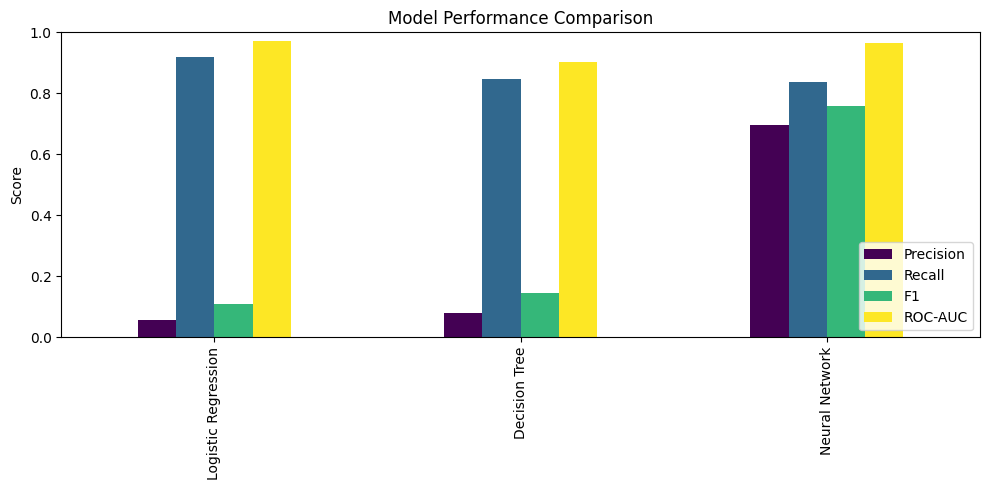

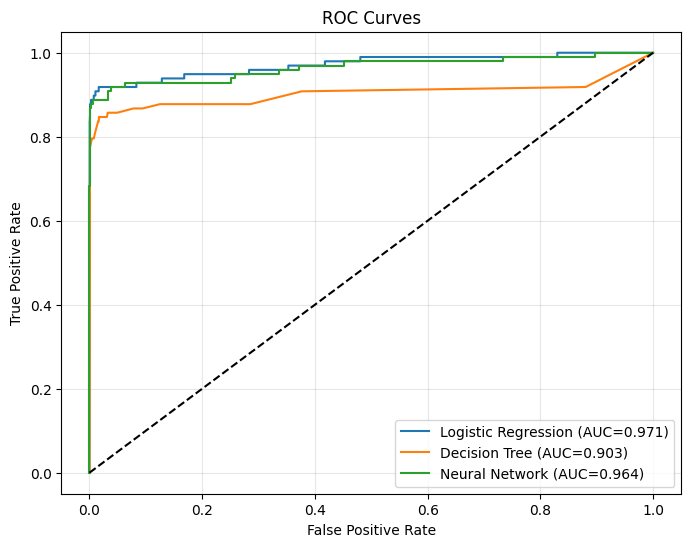

In [8]:
# Compare models
res_df = pd.DataFrame(results).T
print(res_df.to_string(float_format=lambda x: f'{x:.4f}'))

# Visual comparison
res_df.plot(kind='bar', figsize=(10,5), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

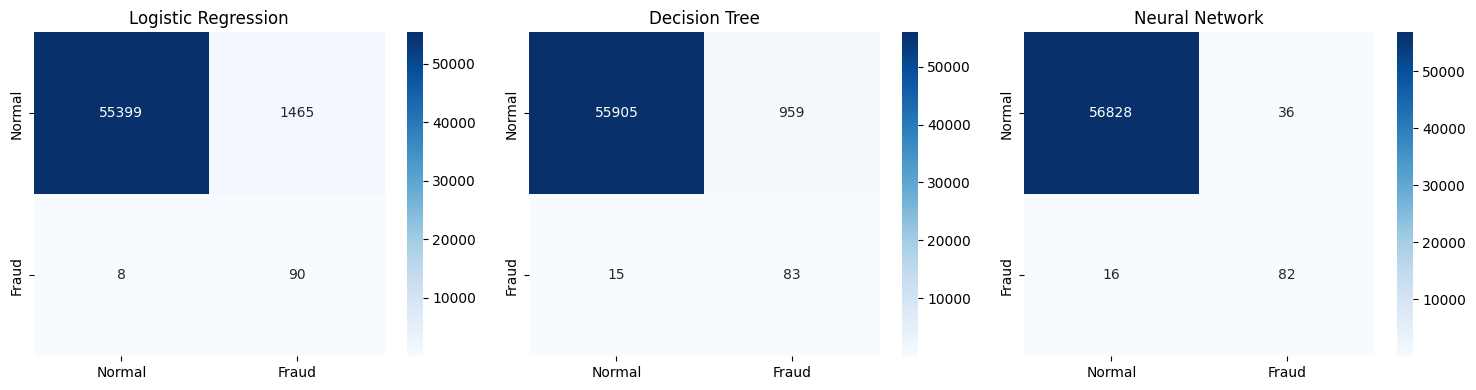

In [9]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normal','Fraud'], yticklabels=['Normal','Fraud'])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()

## 6. Key Learnings

### Anomaly Detection
- Dataset is highly imbalanced (0.17% fraud), making this an anomaly detection problem
- SMOTE helped balance the training data, improving recall significantly

### Feature Engineering
- PCA features V14, V10, V12, V17 are most correlated with fraud
- Log-transforming Amount and creating time-based features improved model performance

### Machine Learning Models
- **Logistic Regression**: Fast, interpretable baseline with good recall
- **Decision Tree**: Rule-based, captures non-linear patterns, easy to explain
- **Neural Network (MLP)**: Best for complex patterns, but slower to train

### Real-time Monitoring
- Deploy model as REST API (Flask/FastAPI) with < 50ms latency
- Use streaming platforms (Kafka/Kinesis) for live transaction ingestion
- Flag suspicious transactions and trigger alerts (email/Slack) in real-time

### Scalability
- Use horizontal scaling (multiple API instances behind load balancer)
- Batch inference during peak hours for efficiency
- Cache frequent user profiles to reduce repeated computations